In [ ]:
#%matplotlib inline
# Use inline backend so HTML(anim.to_jshtml()) renders in the notebook

from spyglass_hexmaze.hex_maze_behavior import HexCentroids, HexMazeBlock
from spyglass_hexmaze.hex_maze_decoding import HexMazeJunctionDecode

from hexmaze import get_critical_choice_points, plot_hex_maze

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from spyglass.common import Nwbfile
import spyglass.common as sgc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# IM-1478
# 28  (10.3, 11.8) # alternation
# 29 (2.8, 4.3) # slightly more imperfect alternation
# 41 (75.5, 78.5) # unchosen
# 54 (3.6, 6.3) # big sweep into unchosen side
# 58 (11.3, 13.4) # heavily favoring chosen side
# 60 (5.0, 6.0) # classic quick alternation
# block 2, 72 (7.3, 10) # long sweep
# Toby
# 7, (1.5, 3.5)
# 16, (10, 11)
# 30, (1.5, 3.25)
## Params
restriction        = "nwb_file_name LIKE '%Toby20250316%'"
block_num          = 1
trial_num          = 30       # which trial to plot (epoch_trial_num)
time_range         = (1.5, 3.25)    # (start, end) seconds relative to trial start; None = full trial
trail_seconds      = 1           # seconds of position trail shown on the maze
fps                = 45          # frames sampled per second of real time
playback_speed     = 0.1         # 1.0 = real time, 0.5 = half speed, 2.0 = double speed

# Fetch
key = (HexMazeJunctionDecode() & restriction).fetch("KEY")[0]
pos_df = (HexMazeJunctionDecode() & key).fetch1_dataframe()

block_key = (HexMazeBlock() & key & {"block": block_num}).fetch1("KEY")
maze, p_a, p_b, p_c = (HexMazeBlock() & block_key).fetch1("config_id", "p_a", "p_b", "p_c")
reward_probs = [int(p_a), int(p_b), int(p_c)]
centroids = HexCentroids().get_core_hex_centroids_dict_cm(block_key)
critical_cps = get_critical_choice_points(maze)

# Fetch the chosen trial's interval
trial_info = (HexMazeBlock.Trial() & block_key & {"epoch_trial_num": trial_num}).fetch1()
trial_start, trial_end = (sgc.IntervalList() & {
    "nwb_file_name": trial_info["nwb_file_name"],
    "interval_list_name": trial_info["interval_list_name"]
}).fetch1("valid_times")[0]

# Apply time range (relative to trial start)
if time_range is None:
    t_plot_start, t_plot_end = trial_start, trial_end
else:
    t_plot_start = trial_start + time_range[0]
    t_plot_end   = trial_start + time_range[1]

df_plot = pos_df.loc[t_plot_start:t_plot_end]

# Build figure with static backgrounds
fig = plt.figure(figsize=(7, 10))
inner = GridSpecFromSubplotSpec(3, 1, subplot_spec=GridSpec(1, 1, figure=fig)[0],
                                height_ratios=[5, 1, 1], hspace=0.05)
ax_maze  = fig.add_subplot(inner[0])
ax_dist  = fig.add_subplot(inner[1])
ax_speed = fig.add_subplot(inner[2], sharex=ax_dist)

plot_hex_maze(ax=ax_maze, barriers=maze, centroids=centroids,
              snap_centroids=True, invert_yaxis=True,
              show_barriers=False, show_hex_labels=False,
              show_stats=True, reward_probabilities=reward_probs)

# Static faded background for time series
match     = df_plot[(df_plot["decode_junction_direction"] == df_plot["rat_junction_direction"]) & df_plot["decode_junction_direction"].isin(["left", "right"])]
mismatch  = df_plot[(df_plot["decode_junction_direction"] != df_plot["rat_junction_direction"]) & df_plot["decode_junction_direction"].isin(["left", "right"]) & df_plot["rat_junction_direction"].isin(["left", "right"])]
ambiguous = df_plot[df_plot["decode_junction_direction"].isin(["ambiguous", "None"])]

for subset, color in [(match, "red"), (mismatch, "blue"), (ambiguous, "gray")]:
    ax_dist.scatter(subset.index - trial_start, subset["decode_distance"], s=2, alpha=0.5, color=color)

ax_speed.scatter(df_plot.index - trial_start, df_plot["speed"], s=2, alpha=0.5, color="gray")
ax_dist.axhline(0, color="k", linewidth=0.5, linestyle="--")

# Axis labels
ax_dist.set_ylabel("Decode distance from rat \n(cm)", fontsize=8);  ax_dist.tick_params(labelsize=10)
plt.setp(ax_dist.get_xticklabels(), visible=False)
ax_speed.set_ylabel("Speed\n(cm/s)", fontsize=8);  ax_speed.tick_params(labelsize=10)
ax_speed.set_xlabel("Time (s)", fontsize=8)

time_label = f"{time_range[0]}-{time_range[1]}s" if time_range else "full trial"
# fig.suptitle(f"{key['nwb_file_name']}  epoch={key['epoch']}  block={block_num}  trial={trial_num}  [{time_label}]",
#              fontsize=10, y=1.0)
# plt.subplots_adjust(top=0.97)
for ax in [ax_maze, ax_dist, ax_speed]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# Animated artists 
# Maze trail (last trail_seconds of positions)
scat_trail_actual   = ax_maze.scatter([], [], s=6,  color="k",    alpha=0.4, zorder=3)
scat_trail_match    = ax_maze.scatter([], [], s=6,  color="red",  alpha=0.4, zorder=2)
scat_trail_mismatch = ax_maze.scatter([], [], s=6,  color="blue", alpha=0.4, zorder=2)
scat_trail_ambig    = ax_maze.scatter([], [], s=6,  color="gray", alpha=0.4, zorder=2)

# Current-position markers (large)
scat_now_actual = ax_maze.scatter([], [], s=120, color="k",    zorder=5, edgecolors="white", linewidths=1)
scat_now_decode = ax_maze.scatter([], [], s=120, color="gray", zorder=4, edgecolors="white", linewidths=1)

# Moving-dot highlights on time series
dot_dist  = ax_dist.scatter([], [], s=20, color="k", zorder=5)
dot_speed = ax_speed.scatter([], [], s=20, color="k", zorder=5)

# Vertical cursor lines on time series
cursors = [ax.axvline(t_plot_start - trial_start, color="k", linewidth=1.2, zorder=10)
           for ax in [ax_dist, ax_speed]]

# Subsample timestamps to target fps
t_vals = df_plot.index.values
n_frames = max(2, int((t_vals[-1] - t_vals[0]) * fps))
frame_indices = np.round(np.linspace(0, len(t_vals) - 1, n_frames)).astype(int)

_empty = np.empty((0, 2))

def _decode_color(row):
    # red = decode matches rat, blue = decode wrong, gray = ambiguous
    d, r = row["decode_junction_direction"], row["rat_junction_direction"]
    if d not in ("left", "right") or r not in ("left", "right"):
        return "gray"
    return "red" if d == r else "blue"

def update(fi):
    idx   = frame_indices[fi]
    t_now = t_vals[idx]
    t_rel = t_now - trial_start

    # Maze trail
    trail = df_plot.loc[t_now - trail_seconds : t_now]
    tm = trail[(trail["decode_junction_direction"] == trail["rat_junction_direction"]) & trail["decode_junction_direction"].isin(["left","right"])]
    tx = trail[(trail["decode_junction_direction"] != trail["rat_junction_direction"]) & trail["decode_junction_direction"].isin(["left","right"]) & trail["rat_junction_direction"].isin(["left","right"])]
    ta = trail[trail["decode_junction_direction"].isin(["ambiguous","None"])]

    scat_trail_actual.set_offsets(trail[["position_x","position_y"]].values)
    scat_trail_match.set_offsets(tm[["decode_position_x","decode_position_y"]].values if len(tm) else _empty)
    scat_trail_mismatch.set_offsets(tx[["decode_position_x","decode_position_y"]].values if len(tx) else _empty)
    scat_trail_ambig.set_offsets(ta[["decode_position_x","decode_position_y"]].values if len(ta) else _empty)

    # Current-position markers
    row = df_plot.iloc[idx]
    scat_now_actual.set_offsets([[row["position_x"], row["position_y"]]])
    scat_now_decode.set_offsets([[row["decode_position_x"], row["decode_position_y"]]])
    scat_now_decode.set_color(_decode_color(row))

    # Time-series dots and cursors
    for c in cursors:
        c.set_xdata([t_rel, t_rel])
    dot_dist.set_offsets([[t_rel, row["decode_distance"]]])
    dot_speed.set_offsets([[t_rel, row["speed"]]])

    return [scat_trail_actual, scat_trail_match, scat_trail_mismatch, scat_trail_ambig,
            scat_now_actual, scat_now_decode,
            dot_dist, dot_speed] + cursors
    

plt.subplots_adjust(left=0.12, right=0.97, top=0.95, bottom=0.08, hspace=0.05)
anim = FuncAnimation(fig, update, frames=n_frames, interval=int(1000 / fps / playback_speed), blit=False)

from matplotlib.animation import FFMpegWriter

writer = FFMpegWriter(
    fps=fps * playback_speed,     # output fps stays correct
    metadata=dict(artist="Me"),
    bitrate=8000,                 # was 1800 — much higher quality
    extra_args=["-vcodec", "libx264", "-pix_fmt", "yuv420p", "-crf", "17"]
    # crf: 0=lossless, 17=near-lossless, 23=default, 51=worst
)
anim.save("Toby20250316_trial30_animation.mp4", writer=writer)

plt.close(fig)
HTML(anim.to_jshtml())


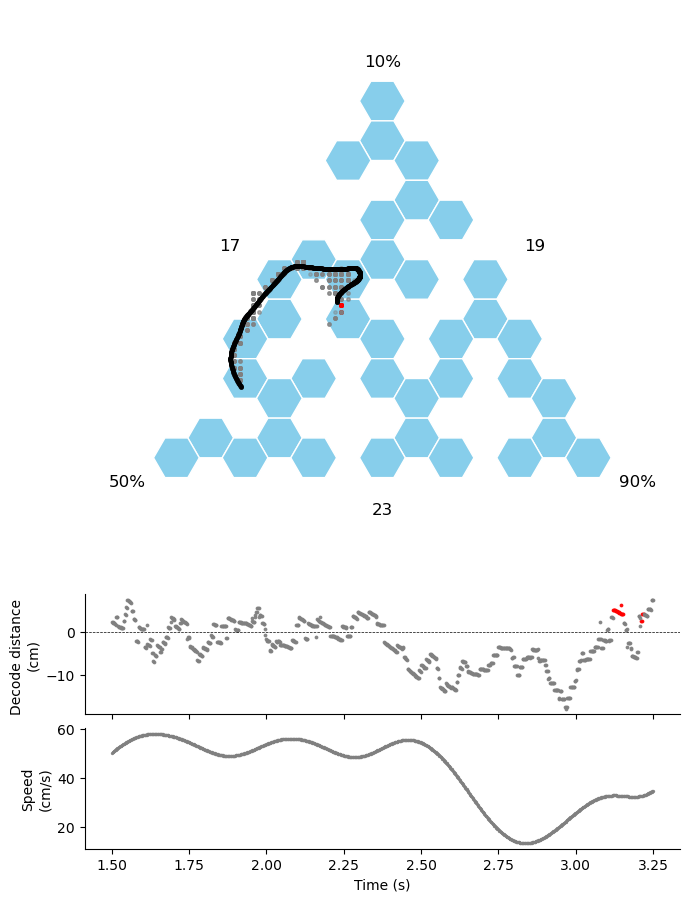

In [ ]:
#%matplotlib inline

from spyglass_hexmaze.hex_maze_behavior import HexCentroids, HexMazeBlock
from spyglass_hexmaze.hex_maze_decoding import HexMazeJunctionDecode
from hexmaze import get_critical_choice_points, plot_hex_maze
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from IPython.display import HTML
from spyglass.common import Nwbfile
import spyglass.common as sgc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Params
restriction    = "nwb_file_name LIKE '%Toby20250316%'"
block_num      = 1
trial_num      = 30
time_range     = (1.5, 3.25)   # seconds relative to trial start; None = full trial

# Fetch
key = (HexMazeJunctionDecode() & restriction).fetch("KEY")[0]
pos_df = (HexMazeJunctionDecode() & key).fetch1_dataframe()

block_key = (HexMazeBlock() & key & {"block": block_num}).fetch1("KEY")
maze, p_a, p_b, p_c = (HexMazeBlock() & block_key).fetch1("config_id", "p_a", "p_b", "p_c")
reward_probs = [int(p_a), int(p_b), int(p_c)]
centroids = HexCentroids().get_core_hex_centroids_dict_cm(block_key)

trial_info = (HexMazeBlock.Trial() & block_key & {"epoch_trial_num": trial_num}).fetch1()
trial_start, trial_end = (sgc.IntervalList() & {
    "nwb_file_name": trial_info["nwb_file_name"],
    "interval_list_name": trial_info["interval_list_name"]
}).fetch1("valid_times")[0]

if time_range is None:
    t_plot_start, t_plot_end = trial_start, trial_end
else:
    t_plot_start = trial_start + time_range[0]
    t_plot_end   = trial_start + time_range[1]

df_plot = pos_df.loc[t_plot_start:t_plot_end]

# Subsets by decode match
match     = df_plot[(df_plot["decode_junction_direction"] == df_plot["rat_junction_direction"]) & df_plot["decode_junction_direction"].isin(["left", "right"])]
mismatch  = df_plot[(df_plot["decode_junction_direction"] != df_plot["rat_junction_direction"]) & df_plot["decode_junction_direction"].isin(["left", "right"]) & df_plot["rat_junction_direction"].isin(["left", "right"])]
ambiguous = df_plot[df_plot["decode_junction_direction"].isin(["ambiguous", "None"])]

# Build figure
fig = plt.figure(figsize=(7, 10))
inner = GridSpecFromSubplotSpec(3, 1, subplot_spec=GridSpec(1, 1, figure=fig)[0],
                                height_ratios=[5, 1, 1], hspace=0.05)
ax_maze  = fig.add_subplot(inner[0])
ax_dist  = fig.add_subplot(inner[1])
ax_speed = fig.add_subplot(inner[2], sharex=ax_dist)

plot_hex_maze(ax=ax_maze, barriers=maze, centroids=centroids,
              snap_centroids=True, invert_yaxis=True,
              show_barriers=False, show_hex_labels=False,
              show_stats=True, reward_probabilities=reward_probs)

# Actual rat position (black trail)
ax_maze.scatter(df_plot["position_x"], df_plot["position_y"],
                s=6, color="k", alpha=0.5, zorder=3)

# Decode positions colored by match/mismatch/ambiguous
ax_maze.scatter(match["decode_position_x"],    match["decode_position_y"],    s=6, color="red",  alpha=0.5, zorder=2)
ax_maze.scatter(mismatch["decode_position_x"], mismatch["decode_position_y"], s=6, color="blue", alpha=0.5, zorder=2)
ax_maze.scatter(ambiguous["decode_position_x"],ambiguous["decode_position_y"],s=6, color="gray", alpha=0.4, zorder=2)

# Time series
for subset, color in [(match, "red"), (mismatch, "blue"), (ambiguous, "gray")]:
    ax_dist.scatter(subset.index - trial_start, subset["decode_distance"], s=3, alpha=0.9, color=color)
ax_speed.scatter(df_plot.index - trial_start, df_plot["speed"], s=2, alpha=0.9, color="gray")
ax_dist.axhline(0, color="k", linewidth=0.5, linestyle="--")

# Labels
ax_dist.set_ylabel("Decode distance \n(cm)", fontsize=10)
ax_dist.tick_params(labelsize=10)
plt.setp(ax_dist.get_xticklabels(), visible=False)
ax_speed.set_ylabel("Speed\n(cm/s)", fontsize=10)
ax_speed.tick_params(labelsize=10)
ax_speed.set_xlabel("Time (s)", fontsize=10)

for ax in [ax_maze, ax_dist, ax_speed]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.subplots_adjust(left=0.12, right=0.97, top=0.95, bottom=0.08, hspace=0.05)
plt.show()
